In [29]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import Subset

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from random import randrange
import math

## **Hyperparameters**

In [30]:
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
VALIDATION_SPLIT = 0.2
ALPHA = 0.5

## **Data loading**

In [31]:
NUM_CLASSES = 6
NUM_SUBJECTS = 30
NUM_CHANNELS = 9
NUM_CONCEPTS = 3

TRAINING_SUBJECTS = 21


activity_labels = {
    0: "WALKING",
    1: "WALKING_UPSTAIRS",
    2: "WALKING_DOWNSTAIRS",
    3: "SITTING",
    4: "STANDING",
    5: "LAYING"
}

data_path = {
    "train": "../data/UCI-HAR/train/",
    "test": "../data/UCI-HAR/test/"
}

signals_path = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z"
]


def split_for_validation (train_dataset):
    val_subjects_split = math.floor(VALIDATION_SPLIT * TRAINING_SUBJECTS)
    train_subjects_split = TRAINING_SUBJECTS - val_subjects_split
    train_subjects = np.loadtxt(data_path["train"] + "subject_train.txt").astype("int")

    counter = 0
    curr_subj = 0
    val_split_start = 0
    for subj in train_subjects:
        val_split_start += 1
        if subj != curr_subj:
            curr_subj = subj
            counter += 1
        if counter == train_subjects_split + 1:
            break

    train_subset = Subset(train_dataset, [i for i in range(0, val_split_start)])
    validation_subset = Subset(train_dataset, [i for i in range (val_split_start, train_dataset.__len__())])

    return (train_subset, validation_subset)


class ConceptHARDataset (Dataset):
    def __init__ (self, type):
        self.labels = np.loadtxt(data_path[type] + "y_" + type + ".txt").astype("int")
        self.subjects = np.loadtxt(data_path[type] + "subject_" + type + ".txt").astype("int")
        self.concepts = np.loadtxt(data_path[type] + "concepts_" + type + ".txt").astype("float32")

        for idx in range(0, len(signals_path)):
            signals = np.loadtxt(data_path[type] + "Inertial Signals/" + signals_path[idx] + "_" + type + ".txt").astype("float32")
            if idx > 0:
                self.data = np.dstack((self.data, signals))
            else:
                self.data = signals

    def __len__ (self):
        return len(self.labels)

    def __getitem__ (self, idx):
        # item: [128, 9]
        item = self.data[idx, :, :]
        item = np.transpose(item)
        label = torch.tensor(self.labels[idx] - 1, dtype=torch.long)
        item_concepts = torch.from_numpy(self.concepts[idx])

        return item, label, item_concepts
    

train_dataset = ConceptHARDataset("train")

train_subset, validation_subset = split_for_validation(train_dataset)
train_dataloader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_subset, batch_size=1, shuffle=False)

test_dataset = ConceptHARDataset("test")
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

## **Model definition**
A simple 1-dimensional CNN consisting of the following modules (with the related input dimension variation):<br>
- **Input**: `[N, 9, 128]`

**First convolutional module**
- **Conv1**: `[N, 9, 128] -> [N, 32, 124]`
- **Activation**: no change
- **Pooling**: `[N, 32, 124] -> [N, 32, 62]`
- **Batch norm**: no change

**Second convolutional module**
- **Conv2**: `[N, 32, 62] -> [N, 16, 60]`
- **Activation**: no change
- **Pooling**: `[N, 16, 60] -> [N, 16, 30]`
- **Batch norm**: no change

**Upstream classification module**
- **Glob. avg. poling**: `[N, 16, 30] -> [N, 16, 1]`
- **Flatten**: `[N, 16, 1] -> [N, 16]`
- **Dense**: `[N, 16] -> [N, 2]`
- **Dense**: `[N, 2] -> [N, 6]`

*Note*: `N` = batch size.

In [32]:
class ConceptModel (nn.Module):
    def __init__ (self, out_classes):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=NUM_CHANNELS, out_channels=32, kernel_size=5)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=16, kernel_size=3)
        self.pooling = nn.MaxPool1d(kernel_size=2)
        self.globAvgPooling = nn.AdaptiveAvgPool1d(1)
        self.concept_dense = nn.Linear(in_features=16, out_features=NUM_CONCEPTS)
        self.class_dense = nn.Linear(in_features=NUM_CONCEPTS, out_features=out_classes)

        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.batchNorm1 = nn.BatchNorm1d(num_features=32, affine=True)
        self.batchNorm2 = nn.BatchNorm1d(num_features=16, affine=True)

    def forward (self, x):
        x = self.batchNorm1(self.pooling(self.activation(self.conv1(x))))
        x = self.batchNorm2(self.pooling(self.activation(self.conv2(x))))
        x = self.globAvgPooling(x)
        x = self.activation(torch.flatten(x, 1))
        c = self.activation(self.concept_dense(x))
        x = self.class_dense(c)
        
        return c, x


model = ConceptModel(NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

## **Joint bottleneck loss**

In [33]:
def joint_bottleneck_loss (out_concept, trg_concept, out_class, trg_class):
    crossentropy = nn.CrossEntropyLoss()

    class_loss = crossentropy(out_class, trg_class)
    concept_loss = crossentropy(out_concept, trg_concept)

    return class_loss + ALPHA * concept_loss

In [34]:
def batch_accuracy (outputs, labels):
    part_acc = 0

    for i in range(0, (outputs.size())[0]):
        y_pred = torch.argmax(outputs[i])

        if y_pred == labels[i]:
            part_acc += 1
        
    return part_acc


def evaluate (model, dataloader):
    acc = 0
    model.eval()

    with torch.no_grad():
        for _, data in enumerate(dataloader):
            inputs, labels, _ = data
            _, outputs = model(inputs)
            acc += batch_accuracy(outputs, labels)

    return round((acc / len(dataloader.dataset) * 100), 2)


def plot_conf_matrix (model, dataloader, title):
    conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES))

    with torch.no_grad():
        for _, data in enumerate(dataloader):
            inputs, labels, _ = data
            _, outputs = model(inputs)

            for i in range(0, (outputs.size())[0]):
                y_pred = torch.argmax(outputs[i])
                y_actual = labels[i]

                conf_matrix[y_actual][y_pred] += 1

    labels = ["WALKING", "WALKING UPSTAIRS", "WALKING DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]

    _, ax = plt.subplots()
    ax.xaxis.set_label_position("top")
    ax.yaxis.set_label_position("right")
    sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="g", xticklabels=labels, yticklabels=labels, cbar=False)
    plt.title(title, fontsize=20, pad=10)
    plt.xlabel("Predicted class", fontsize=14)
    plt.ylabel("Actual class", fontsize=14)
    plt.show()

Starting point
Train accuracy: 22.22%
Validation accuracy: 22.78%



Training on 100 epochs: 100%|██████████| 100/100 [07:59<00:00,  4.80s/it]


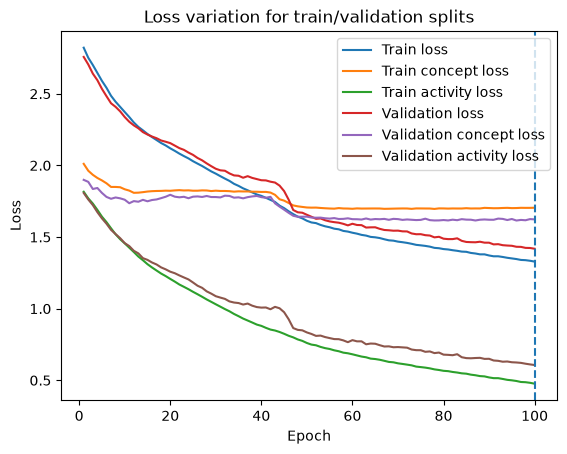

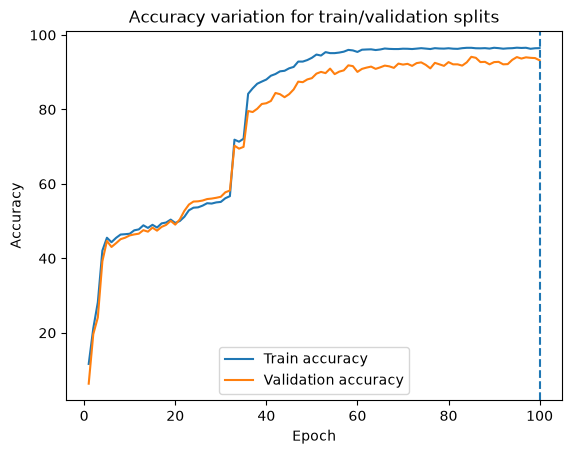

Best validation loss: 1.4183
Final validation accuracy:  93.19%


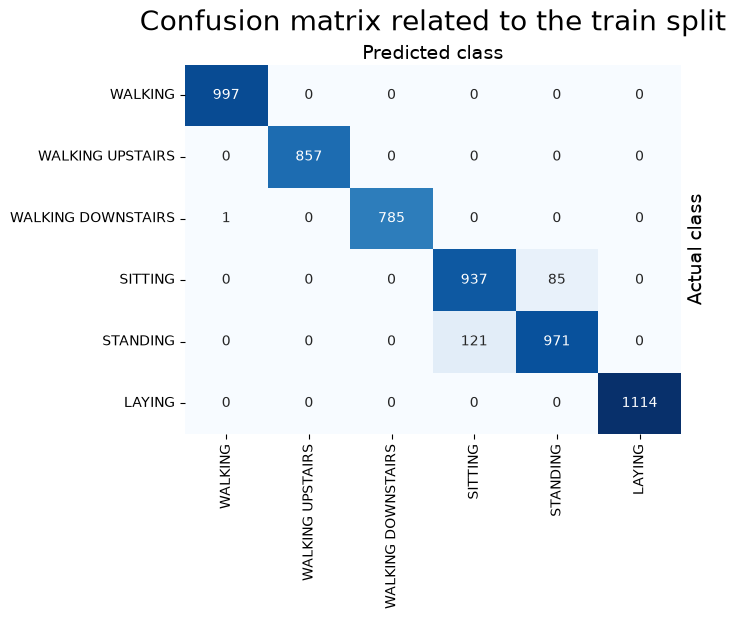

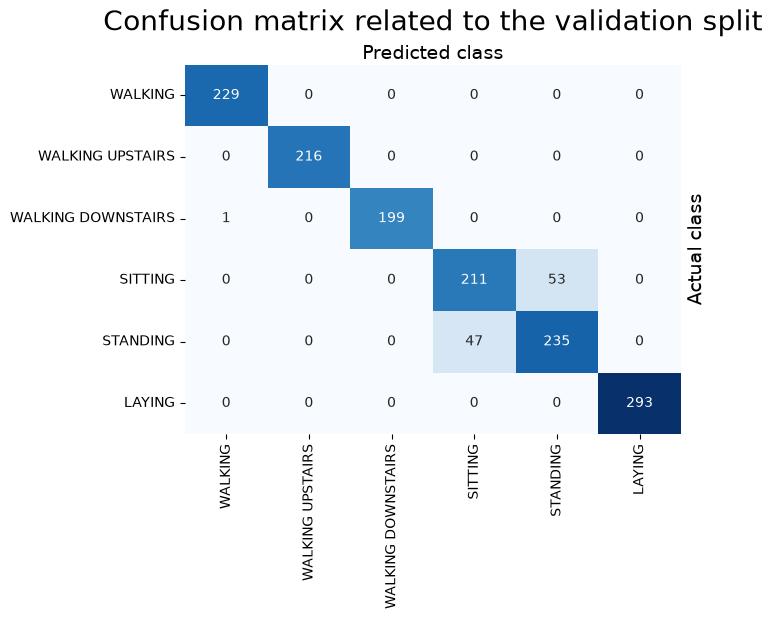

In [35]:
NUM_EPOCHS = 100


print("Starting point")
print("Train accuracy: {0}%".format(evaluate(model, train_dataloader)))
print("Validation accuracy: {0}%\n".format(evaluate(model, validation_dataloader)))

y_train_loss = []
y_train_concept_loss = []
y_train_activity_loss = []
y_val_loss = []
y_val_concept_loss = []
y_val_activity_loss = []

y_train_acc = []
y_val_acc = []

best_val_loss = float("inf")
best_epoch = 0
final_val_acc = 0
best_model = None


# Iterating through the epochs
for epoch in tqdm(range(0, NUM_EPOCHS), desc="Training on " + str(NUM_EPOCHS) + " epochs"):

    # The model is set in training mode
    model.train()

    train_loss = 0
    train_concept_loss = 0
    train_activity_loss = 0
    # Iterating through the batches
    for i, data in enumerate(train_dataloader):
        inputs, labels, concepts = data
        
        # The optimization gradients are reset
        optimizer.zero_grad()

        # The current batch is forwarded to the network
        out_concepts, outputs = model(inputs)

        # Loss related to the concept classification
        concept_loss = criterion(out_concepts, concepts)
        # Loss related to the upstream activity classification
        activity_loss = criterion(outputs, labels)
        train_concept_loss += concept_loss.item()
        train_activity_loss += activity_loss.item()

        # Joint bottleneck loss
        loss = activity_loss + ALPHA * concept_loss
        train_loss += loss.item()

        # Backpropagation 
        loss.backward()
        # Parameters update
        optimizer.step()

    # The model is set in evaluation mode
    model.eval()
    val_loss = 0
    val_concept_loss = 0
    val_activity_loss = 0

    with torch.no_grad():
        for i, data in enumerate(validation_dataloader):
            inputs, labels, concepts = data
            out_concepts, outputs = model(inputs)

            # Loss related to the concept classification
            concept_loss = criterion(out_concepts, concepts)
            # Loss related to the upstream activity classification
            activity_loss = criterion(outputs, labels)

            val_concept_loss += concept_loss.item()
            val_activity_loss += activity_loss.item()

            # Joint bottleneck loss
            loss = activity_loss + ALPHA * concept_loss
            val_loss += loss.item()

    # Epoch loss calculation
    train_loss = round(train_loss / len(train_dataloader), 4)
    train_concept_loss = round(train_concept_loss / len(train_dataloader), 4)
    train_activity_loss = round(train_activity_loss / len(train_dataloader), 4)

    val_loss = round(val_loss / len(validation_dataloader), 4)
    val_concept_loss = round(val_concept_loss / len(validation_dataloader), 4)
    val_activity_loss = round(val_activity_loss / len(validation_dataloader), 4)

    y_train_loss.append(train_loss)
    y_train_concept_loss.append(train_concept_loss)
    y_train_activity_loss.append(train_activity_loss)
    y_val_loss.append(val_loss)
    y_val_concept_loss.append(val_concept_loss)
    y_val_activity_loss.append(val_activity_loss)

    # Epoch accuracy calculation
    train_acc = evaluate(model, train_dataloader)
    val_acc = evaluate(model, validation_dataloader)
    y_train_acc.append(train_acc)
    y_val_acc.append(val_acc)

    # Best model update
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        final_val_acc = val_acc
        best_epoch = epoch + 1
        best_model = model.state_dict()



x = np.linspace(1, NUM_EPOCHS, NUM_EPOCHS)
# Plotting the loss variation of the training and validation splits
plt.plot(x, y_train_loss, label="Train loss")
plt.plot(x, y_train_concept_loss, label="Train concept loss")
plt.plot(x, y_train_activity_loss, label="Train activity loss")

plt.plot(x, y_val_loss, label="Validation loss")
plt.plot(x, y_val_concept_loss, label="Validation concept loss")
plt.plot(x, y_val_activity_loss, label="Validation activity loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss variation for train/validation splits")
plt.legend()
plt.axvline(x=best_epoch, linestyle="dashed")
plt.show()

# Plotting the accuracy variation of the training and validation splits
plt.plot(x, y_train_acc, label="Train accuracy")
plt.plot(x, y_val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy variation for train/validation splits")
plt.legend()
plt.axvline(x=best_epoch, linestyle="dashed")
plt.show()

print("Best validation loss:", best_val_loss)
print("Final validation accuracy: ", str(final_val_acc) + "%")

# Plotting the confusion matrices for train/validation splits
plot_conf_matrix(model, train_dataloader, title="Confusion matrix related to the train split")
plot_conf_matrix(model, validation_dataloader, title="Confusion matrix related to the validation split")
